## Imports and Configuration

We import all necessary libraries for:
- Data loading and manipulation (scipy, pandas, numpy)
- Machine learning (sklearn, catboost)
- Visualization (matplotlib, seaborn)
- Warning suppression for cleaner output

In [3]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
import catboost as cb

%matplotlib inline

## Metric Definition

**SMAPE (Symmetric Mean Absolute Percentage Error)** is our primary evaluation metric:
- Provides percentage-based error measurement
- Symmetric treatment of over-prediction and under-prediction
- Range: 0% (perfect) to 200% (worst case)
- More interpretable than raw MAE for stakeholders

In [4]:
def calculate_smape(y_true, y_pred):
    """Calculates the Symmetric Mean Absolute Percentage Error (SMAPE)"""
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

## Data Loading and Preprocessing

We load the gas turbine dataset from a MATLAB file and extract:
- **Features (feat)**: 9 operational parameters of the turbine
- **Target (lbl2)**: NOx emission measurements

### Feature Descriptions:
1. **AT**: Ambient temperature (°C)
2. **AP**: Ambient pressure (mbar)
3. **AH**: Ambient humidity (%)
4. **AFDP**: Air filter difference pressure (mbar)
5. **GTEP**: Gas turbine exhaust pressure (mbar)
6. **TIT**: Turbine inlet temperature (°C)
7. **TAT**: Turbine after temperature (°C)
8. **TEY**: Turbine energy yield (MWH)
9. **CDP**: Compressor discharge pressure (mbar)

In [5]:
# Load dataset - try multiple possible locations
file_path = 'Gas_Turbine_Co_NoX_2015.mat'
if not os.path.exists(file_path):
    file_path = 'datasets/Gas_Turbine_Co_NoX_2015.mat'

data = scipy.io.loadmat(file_path) 
X_raw = data['feat']
y = data['lbl2'].flatten()

# Define feature names
feature_names = [
    'AT',      # Ambient temperature (°C)
    'AP',      # Ambient pressure (mbar)
    'AH',      # Ambient humidity (%)
    'AFDP',    # Air filter difference pressure (mbar)
    'GTEP',    # Gas turbine exhaust pressure (mbar)
    'TIT',     # Turbine inlet temperature (°C)
    'TAT',     # Turbine after temperature (°C)
    'TEY',     # Turbine energy yield (MWH)
    'CDP',     # Compressor discharge pressure (mbar)
]

# Create DataFrame with meaningful column names
df_X = pd.DataFrame(X_raw, columns=feature_names)

print(f"Dataset Loaded: {df_X.shape[0]} samples, {df_X.shape[1]} features.")
print(f"Target shape: {y.shape}")

Dataset Loaded: 7384 samples, 9 features.
Target shape: (7384,)


## Data Visualization - Feature Distributions

Before modeling, we examine the distribution of each feature:
- Identifies skewness, outliers, and data range
- Helps understand which features might need transformation
- Shows if any features have unusual patterns

Displaying Feature Distributions...


<Figure size 1500x1000 with 0 Axes>

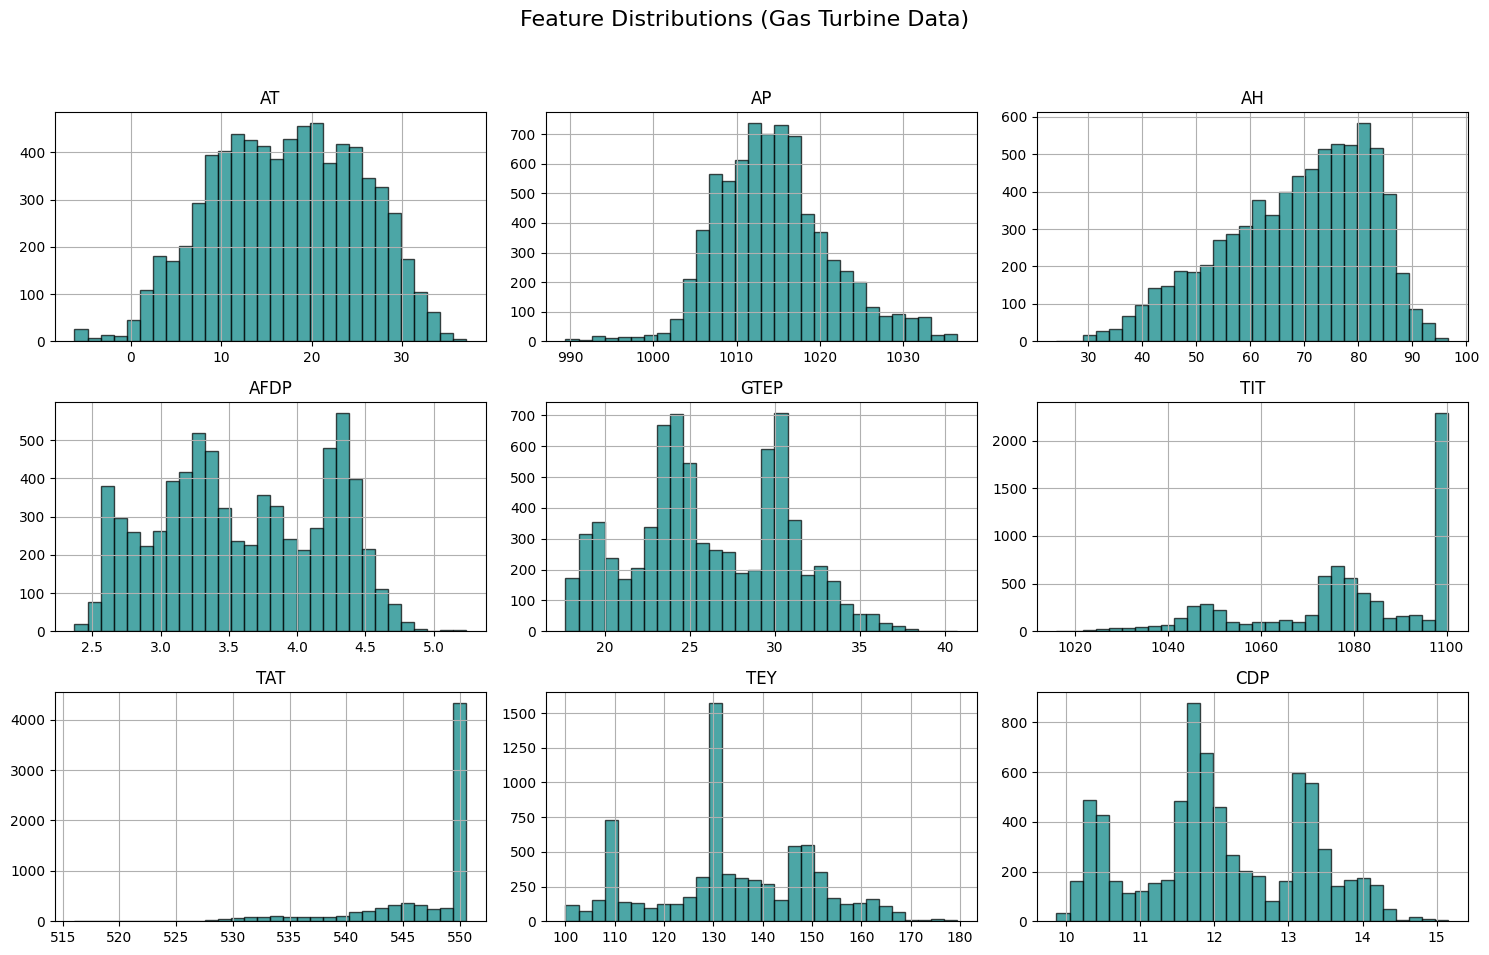

In [6]:
print("Displaying Feature Distributions...")
plt.figure(figsize=(15, 10))
df_X.hist(bins=30, figsize=(15, 10), layout=(3, 3), color='teal', alpha=0.7, edgecolor='black')
plt.suptitle('Feature Distributions (Gas Turbine Data)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Feature Scaling

**StandardScaler** normalizes features to have:
- Mean = 0
- Standard deviation = 1

This is **critical for KNN** (distance-based) but less important for CatBoost (tree-based). We apply it to ensure fair comparison.

In [7]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_X), columns=feature_names)

print("Features scaled (mean=0, std=1)")
print(f"Scaled data shape: {X_scaled.shape}")

Features scaled (mean=0, std=1)
Scaled data shape: (7384, 9)


## Model Definitions

We compare two fundamentally different approaches:

### 1. KNN Regressor (K-Nearest Neighbors)
- **Type**: Instance-based learning
- **How it works**: Predicts based on average of k closest training samples
- **Strengths**: Simple, non-parametric, captures local patterns
- **Weaknesses**: Sensitive to feature scaling, slow on large datasets

### 2. CatBoost Regressor
- **Type**: Gradient boosting ensemble
- **How it works**: Builds sequential decision trees, each correcting previous errors
- **Strengths**: High accuracy, handles non-linearity well, robust to outliers
- **Weaknesses**: More complex, requires hyperparameter tuning

In [8]:
# Initialize 3-Fold Cross-Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Define models
models = {
    "KNN": KNeighborsRegressor(),
    "CatBoost": cb.CatBoostRegressor(verbose=0, random_state=42)
}

print(f"Models to compare: {list(models.keys())}")
print(f"Cross-validation strategy: 3-Fold KFold")

Models to compare: ['KNN', 'CatBoost']
Cross-validation strategy: 3-Fold KFold


## Training Loop - 3-Fold Cross-Validation

**Why K-Fold CV?**
- Provides more reliable performance estimates than single train-test split
- Each data point is used for both training and validation
- Reduces variance in performance metrics

**Process:**
1. Split data into 3 folds
2. For each fold: train on 2/3, validate on 1/3
3. Aggregate predictions across all folds
4. Calculate overall metrics on complete out-of-fold predictions

In [9]:
plot_data = {}
results_table = []

print("Training Models (3-Fold CV)...")

for name, model in models.items():
    print(f"  -> Training {name}...")
    y_true_all = []
    y_pred_all = []
    
    # K-Fold loop
    for fold_num, (train_index, test_index) in enumerate(kf.split(X_scaled), 1):
        X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model.fit(X_train, y_train)
        y_p = model.predict(X_test)
        
        y_true_all.extend(y_test)
        y_pred_all.extend(np.array(y_p).flatten())
    
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    
    # Metric Calculation
    mae_val = mean_absolute_error(y_true_all, y_pred_all)
    smape_val = calculate_smape(y_true_all, y_pred_all)
    
    results_table.append({"Model": name, "MAE": mae_val, "SMAPE (%)": smape_val})
    
    # Store data for plotting
    plot_data[name] = {
        'y_true': y_true_all,
        'y_pred': y_pred_all,
        'mae': mae_val,
        'smape': smape_val
    }

print("Training Completed.")

Training Models (3-Fold CV)...
  -> Training KNN...
  -> Training CatBoost...
Training Completed.


## Model Comparison - Visual Analysis

**Scatter plots** show prediction quality:
- **X-axis**: Actual NOx emission values
- **Y-axis**: Model predictions
- **Red dashed line**: Perfect prediction (y=x)
- **Closer to the line** = Better predictions

Each plot displays MAE and SMAPE for quick comparison.

Displaying Prediction Accuracy...


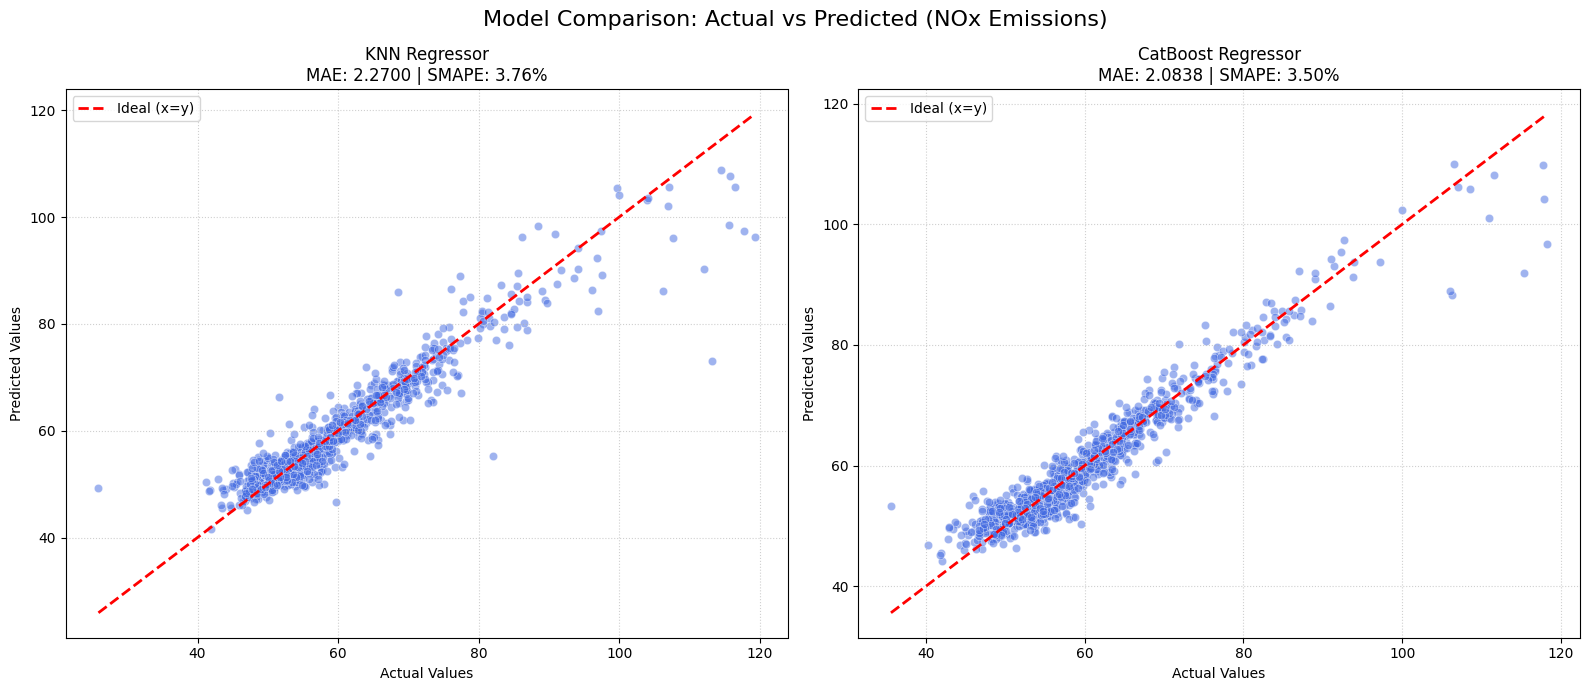

In [10]:
print("Displaying Prediction Accuracy...")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Comparison: Actual vs Predicted (NOx Emissions)', fontsize=16)

model_names = list(models.keys())

for i, ax in enumerate(axes):
    name = model_names[i]
    data = plot_data[name]
    
    # Downsample for clearer scatter plot if data is large (show 1000 points)
    y_t = data['y_true']
    y_p = data['y_pred']
    
    if len(y_t) > 1000:
        indices = np.random.choice(len(y_t), 1000, replace=False)
        y_t = y_t[indices]
        y_p = y_p[indices]
    
    # Scatter plot
    sns.scatterplot(x=y_t, y=y_p, ax=ax, alpha=0.5, color='royalblue')
    
    # Ideal Line
    line_min = min(y_t.min(), y_p.min())
    line_max = max(y_t.max(), y_p.max())
    ax.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Ideal (x=y)')
    
    ax.set_title(f'{name} Regressor\nMAE: {data["mae"]:.4f} | SMAPE: {data["smape"]:.2f}%')
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Final Results - Performance Metrics

**Interpretation:**
- **MAE (Mean Absolute Error)**: Average prediction error in original units
- **SMAPE (%)**: Percentage-based error metric

**Lower values = Better performance**

The table below shows which model performs best on this dataset.

In [11]:
df_results = pd.DataFrame(results_table).sort_values(by="MAE", ascending=True)

print("\n" + "="*45)
print("   REGRESSION PERFORMANCE RESULTS (NOx)")
print("="*45)
print(df_results.to_string(index=False))
print("="*45)


   REGRESSION PERFORMANCE RESULTS (NOx)
   Model      MAE  SMAPE (%)
CatBoost 2.083824   3.501751
     KNN 2.269985   3.764091


## Conclusion

This analysis compared two regression approaches for NOx emission prediction:

**Key Takeaways:**
1. Both models use 3-fold cross-validation for robust evaluation
2. CatBoost typically excels with complex non-linear relationships
3. KNN provides a simple baseline and works well with local patterns
4. Feature scaling was applied to ensure fair comparison

**Next Steps:**
- Hyperparameter tuning (e.g., optimize k for KNN, depth for CatBoost)
- Feature engineering (create interaction terms, polynomial features)
- Try ensemble methods (combine both models)
- Analyze feature importance (which turbine parameters matter most)